In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [25]:
df = pd.read_csv("../../data/diabetes.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 614
Testing Samples: 154


In [27]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
    def evaluate_model_with_model(name, model, X_train, X_test):
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            y_prob = model.predict_proba(X_test)[:, 1]
        else:
            y_prob = model.decision_function(X_test)

        return model, y_prob

    lr_model, probs_lr = evaluate_model_with_model(
        "Logistic Regression", LogisticRegression(max_iter=1000), X_train_scaled, X_test_scaled
    )

    svm_model, probs_svm = evaluate_model_with_model(
        "SVM", SVC(probability=True), X_train_scaled, X_test_scaled
    )

    rf_model, probs_rf = evaluate_model_with_model(
        "Random Forest", RandomForestClassifier(n_estimators=100, random_state=42), X_train, X_test
    )

    mlp_model, probs_mlp = evaluate_model_with_model(
        "MLP", MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42), X_train_scaled, X_test_scaled
    )

c:\Users\neeli\OneDrive\Desktop\disease-ai-intern\.venv311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


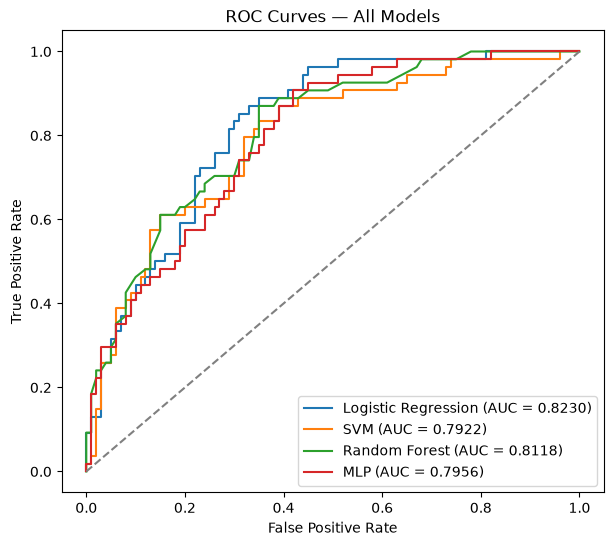

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

for name, probs in [
    ("Logistic Regression", probs_lr),
    ("SVM", probs_svm),
    ("Random Forest", probs_rf),
    ("MLP", probs_mlp),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()

plt.savefig("../../results/week 4/roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [30]:
results = []
results.append(
    evaluate_model(
        "Logistic Regression",
        LogisticRegression(max_iter=1000),
        X_train_scaled,
        X_test_scaled
    )
)

results.append(
    evaluate_model(
        "SVM",
        SVC(probability=True),
        X_train_scaled,
        X_test_scaled
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),
        X_train,
        X_test
    )
)

results.append(
    evaluate_model(
        "MLP",
        MLPClassifier(
            hidden_layer_sizes=(100,),
            max_iter=500,
            random_state=42
        ),
        X_train_scaled,
        X_test_scaled
    )
)

NameError: name 'evaluate_model' is not defined

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC


In [ ]:
results_df.to_csv(
    "../results/results_log.csv",
    index=False
)

print("results_log.csv saved successfully!")

results_log.csv saved successfully!


In [ ]:
best_model = results_df.loc[
    results_df["F1 Score"].idxmax()
]

print("Best Model based on F1 Score:")
print(best_model)

Best Model based on F1 Score:
Model           SVM
Accuracy     0.7532
Precision      0.66
Recall       0.6111
F1 Score     0.6346
ROC-AUC      0.7919
Name: 1, dtype: object


In [ ]:
best_model_name = best_model["Model"]
best_f1 = best_model["F1 Score"]

print(best_model_name, best_f1)

SVM 0.6346
